# Template Notebook

## Setup Environment

In [1]:
# Import Python Standard Libraries
import os
from pathlib import Path

# Import third party libraries
import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns


# Import local libraries

### Setup Plotting Styles

In [2]:
sns.set_style('whitegrid', {'legend.frameon': True})
sns.set_context('talk')

### Setup how pandas displays data

In [3]:
pd.options.display.max_rows = 27
pd.options.display.max_columns = 20
pd.options.display.precision = 4
pd.options.display.expand_frame_repr = False

### Setup Paths

In [4]:
db_con = {
    "ip": "192.168.1.14",
    "port": "3306",
    "user": "mqttlogger",
    "password": "REDACTED_DB_PASS",
    "database": "sensorreadings",
}

In [5]:
con_string = f"mysql+mysqldb://{db_con['user']}:{db_con['password']}@{db_con['ip']}:{db_con['port']}/{db_con['database']}"

In [6]:
data_df = pd.read_sql_table("sensorreadings", con_string)
data_df["datetime"] = pd.to_datetime(data_df["currentdate"].astype(str) + data_df["currenttime"].astype(str), format="%Y-%m-%d%H:%M:%S")
data_df

,id,currentdate,currenttime,device,reading,datetime
0,1,2021-04-16,13:40:33,humidity_office,43.0,2021-04-16 13:40:33
1,2,2021-04-16,13:40:33,temperature_office,20.2,2021-04-16 13:40:33
2,3,2021-04-16,13:40:33,humidity_office,43.0,2021-04-16 13:40:33
3,4,2021-04-16,13:40:33,temperature_office,20.2,2021-04-16 13:40:33
4,5,2021-04-16,13:40:36,humidity_office,43.0,2021-04-16 13:40:36
...,...,...,...,...,...,...
11105,11116,2021-07-08,03:52:03,environment/indoor/office/temperature,22.4,2021-07-08 03:52:03
11106,11117,2021-07-08,04:12:53,environment/outdoor/patio/temperature,19.3,2021-07-08 04:12:53
11107,11118,2021-07-08,05:06:27,environment/outdoor/patio/temperature,19.2,2021-07-08 05:06:27
11108,11119,2021-07-08,05:06:27,environment/outdoor/patio/humidity,78.0,2021-07-08 05:06:27


## Load Data

In [7]:
for sensor, sensor_df in data_df.groupby("device"):
    print(sensor)


environment/indoor/cellar/fan_status
environment/indoor/cellar_back/humidity
environment/indoor/cellar_back/temperature
environment/indoor/cellar_front/humidity
environment/indoor/cellar_front/temperature
environment/indoor/office/humidity
environment/indoor/office/temperature
environment/outdoor/patio/humidity
environment/outdoor/patio/temperature
hum_cellar_back
hum_cellar_front
hum_patio
humidity/bedroom
humidity_office
temp_cellar_back
temp_cellar_front
temp_patio
temperature/bedroom
temperature_office


## Magic

<AxesSubplot:xlabel='datetime', ylabel='reading'>

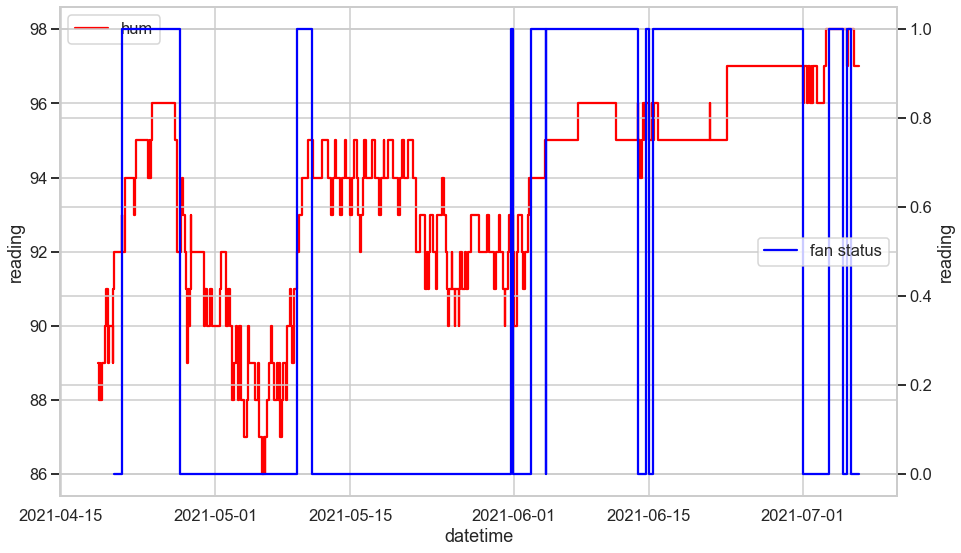

In [8]:
fig_text, ax_test = plt.subplots(1, 1, figsize=(15, 9))
ax2 = ax_test.twinx()
sns.lineplot(x="datetime", y="reading", data=data_df.loc[data_df["device"].str.contains("environment/indoor/cellar_front/humidity")], drawstyle="steps-pre", ax=ax_test, label="hum", color="r")
sns.lineplot(x="datetime", y="reading", data=data_df.loc[data_df["device"].str.contains("fan_status")], label="fan status", ax=ax2, color="b", drawstyle="steps-pre")